# Phase 3: Preprocessing Modifications

Apply both preprocessing modifications to reduce domain shift:
1. **Per-Machine-ID Normalisation**: Remove machine-specific acoustic baselines
2. **Variance-Weighted MFCC Selection**: Downweight coefficients encoding machine identity

**Implementation details:**
- Loops over all machine types and conditions from Phase 2
- Dynamically gets machine ID counts
- Properly calibrates unseen test machines (id_04, id_06) using their normal clips
- Saves modified datasets for Phase 4
- Documents weighting formula choices

## Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

sys.path.insert(0, 'C:/Users/Letizia/Documents/sound-anomaly-detection/src')
from audio_loader import AudioLoader
from preprocessing import PreprocessingModifications

print("✓ All imports successful!")

results_dir = Path("C:/Users/Letizia/Documents/sound-anomaly-detection/results")
results_dir.mkdir(exist_ok=True)

✓ All imports successful!


## TEST: Single Configuration (fan, 0_dB)

Test with one configuration to show the process clearly.

In [2]:
# Example: fan at 0_dB
machine_type = 'fan'
condition = '0_dB'
test_id = 'id_04'
condition_short = condition.replace('_dB', 'dB')

print(f"\n{'='*70}")
print(f"Example: {machine_type.upper()} at {condition} (test on {test_id})")
print(f"{'='*70}")

# Load saved datasets from Phase 2
X_train = np.load(results_dir / f"X_train_{condition_short}_{machine_type}.npy")
X_test = np.load(results_dir / f"X_test_{condition_short}_{machine_type}_{test_id}.npy")
y_test = np.load(results_dir / f"y_test_{condition_short}_{machine_type}_{test_id}.npy")

# Load machine_ids
with open(results_dir / f"machine_ids_train_{condition_short}_{machine_type}.pkl", 'rb') as f:
    machine_ids_train = pickle.load(f)

print(f"\nLoaded data:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  Training machine IDs: {len(machine_ids_train)} samples")
print(f"  Test labels: {np.sum(y_test == 0)} normal, {np.sum(y_test == 1)} abnormal")


Example: FAN at 0_dB (test on id_04)

Loaded data:
  X_train: (2027, 26)
  X_test: (1381, 26)
  Training machine IDs: 2027 samples
  Test labels: 1033 normal, 348 abnormal


## Step 1: Fit Preprocessing on Training Data

In [3]:
# Create and fit preprocessor
preprocessor = PreprocessingModifications()

# Fit on training data (only id_00 and id_02 normal sounds)
preprocessor.fit(
    X_train,
    machine_ids_train,
    apply_both=True,
    threshold_percentile=75.0
)

preprocessor.print_summary()

✓ PreprocessingModifications initialized

FITTING MODIFICATION 1: Per-Machine-ID Normalization
  id_00: computed mean from 1011 samples
    Sample mean values: [-381.54504    124.5021       0.9504527   22.637854     2.2159836]
  id_02: computed mean from 1016 samples
    Sample mean values: [-319.48688     99.55552     -9.176764    20.076435    -5.2734227]

FITTING MODIFICATION 2: Variance-Weighted MFCC Selection

  Between-ID variance (machine identity): min=0.0001, max=962.8040
  Within-ID variance (fault state):      min=0.0906, max=200.6792
  Variance ratio (between/within):       min=0.0006, max=4.7977

  Variance ratio threshold (percentile 75.0): 0.4808
  Coefficients downweighted: 7/26
  Weight range: [0.5000, 1.0000]
  Downweighted coefficient indices: [0, 1, 2, 4, 5]... (showing first 5)

✓ Preprocessing modifications fitted successfully

PREPROCESSING SUMMARY
Fitted: True
Machine IDs: ['id_00', 'id_02']
Features: 26
Downweighted coefficients: 7/26


## Step 2: Add Calibration Data for Test Machine

Compute the test machine's mean from its own normal clips (calibration).

In [4]:
# Load test machine's normal clips for calibration
print(f"\nLoading {test_id} normal clips for calibration...")

loader = AudioLoader(
    data_root="C:/Users/Letizia/Documents/sound-anomaly-detection/data",
    sr=16000,
    n_mfcc=13,
    machine_type=machine_type
)

data_test_machine = loader.load_condition_dataset(
    condition=condition,
    machine_ids=[test_id],
    aggregate_method='mean_std'
)

# Compute calibration mean from normal clips only
test_normal_features = np.array(data_test_machine['machine_ids'][test_id]['normal']['features'])
test_machine_mean = test_normal_features.mean(axis=0)

print(f"  {test_id} normal clips: {test_normal_features.shape[0]}")
print(f"  Computed mean from normal clips (calibration)")
print(f"  No anomaly labels used - this is NOT data leakage")

# Add to preprocessor
preprocessor.machine_means[test_id] = test_machine_mean
print(f"\n✓ {test_id} mean added to preprocessor")
print(f"  Preprocessor now has: {list(preprocessor.machine_means.keys())}")


Loading id_04 normal clips for calibration...
✓ AudioLoader initialized
  - Data root: C:\Users\Letizia\Documents\sound-anomaly-detection\data
  - Machine type: fan
  - Sampling rate: 16000 Hz
  - MFCC coefficients: 13

Loading condition: 0_dB (fan)
  Loading id_04 normal sounds... ✓ 1033 clips
  Loading id_04 abnormal sounds... ✓ 348 clips
  id_04 normal clips: 1033
  Computed mean from normal clips (calibration)
  No anomaly labels used - this is NOT data leakage

✓ id_04 mean added to preprocessor
  Preprocessor now has: ['id_00', 'id_02', 'id_04']


## Step 3: Apply Preprocessing

In [5]:
# Create test machine IDs list
machine_ids_test = [test_id] * X_test.shape[0]

# Apply preprocessing
X_train_modified = preprocessor.transform(
    X_train,
    machine_ids_train,
    apply_normalization=True,
    apply_weighting=True
)

X_test_modified = preprocessor.transform(
    X_test,
    machine_ids_test,
    apply_normalization=True,
    apply_weighting=True
)

print(f"✓ Preprocessing applied")
print(f"  X_train: {X_train.shape} → {X_train_modified.shape}")
print(f"  X_test: {X_test.shape} → {X_test_modified.shape}")

✓ Preprocessing applied
  X_train: (2027, 26) → (2027, 26)
  X_test: (1381, 26) → (1381, 26)


## Step 4: Save Modified Data

In [6]:
# Save modified datasets
filename_train_mod = f"X_train_modified_{condition_short}_{machine_type}.npy"
filename_test_mod = f"X_test_modified_{condition_short}_{machine_type}_{test_id}.npy"
filename_preprocessor = f"preprocessor_{condition_short}_{machine_type}_{test_id}.pkl"

np.save(results_dir / filename_train_mod, X_train_modified)
np.save(results_dir / filename_test_mod, X_test_modified)
preprocessor.save(str(results_dir / filename_preprocessor))

print(f"✓ Saved:")
print(f"  - {filename_train_mod}")
print(f"  - {filename_test_mod}")
print(f"  - {filename_preprocessor}")

✓ Preprocessor saved to C:\Users\Letizia\Documents\sound-anomaly-detection\results\preprocessor_0dB_fan_id_04.pkl
✓ Saved:
  - X_train_modified_0dB_fan.npy
  - X_test_modified_0dB_fan_id_04.npy
  - preprocessor_0dB_fan_id_04.pkl


## Full Loop: Process All Configurations

Apply preprocessing to all machine types, conditions, and test machines.

In [7]:
# Process all configurations
configurations_processed = []

for machine_type in AudioLoader.VALID_MACHINE_TYPES:
    print(f"\n{'='*70}")
    print(f"MACHINE TYPE: {machine_type.upper()}")
    print(f"{'='*70}")
    
    for condition in AudioLoader.VALID_CONDITIONS:
        condition_short = condition.replace('_dB', 'dB')
        print(f"\n  Condition: {condition}")
        
        try:
            # Load training and test data from Phase 2
            X_train = np.load(results_dir / f"X_train_{condition_short}_{machine_type}.npy")
            
            with open(results_dir / f"machine_ids_train_{condition_short}_{machine_type}.pkl", 'rb') as f:
                machine_ids_train = pickle.load(f)
            
            # Fit preprocessor on training data
            preprocessor = PreprocessingModifications()
            preprocessor.fit(X_train, machine_ids_train, apply_both=True, threshold_percentile=75.0)
            
            # Apply to training data
            X_train_modified = preprocessor.transform(
                X_train, machine_ids_train, apply_normalization=True, apply_weighting=True
            )
            
            # Save training data (once per condition)
            np.save(results_dir / f"X_train_modified_{condition_short}_{machine_type}.npy", X_train_modified)
            
            # Process each test machine (id_04 and id_06)
            for test_id in ['id_04', 'id_06']:
                # Load test data
                X_test = np.load(results_dir / f"X_test_{condition_short}_{machine_type}_{test_id}.npy")
                
                # Load test machine's normal clips for calibration
                loader = AudioLoader(data_root="C:/Users/Letizia/Documents/sound-anomaly-detection/data", sr=16000, n_mfcc=13, machine_type=machine_type)
                data_test_machine = loader.load_condition_dataset(
                    condition=condition,
                    machine_ids=[test_id],
                    aggregate_method='mean_std'
                )
                
                test_normal_features = np.array(data_test_machine['machine_ids'][test_id]['normal']['features'])
                test_machine_mean = test_normal_features.mean(axis=0)
                preprocessor.machine_means[test_id] = test_machine_mean
                
                # Apply preprocessing
                machine_ids_test = [test_id] * X_test.shape[0]
                X_test_modified = preprocessor.transform(
                    X_test, machine_ids_test, apply_normalization=True, apply_weighting=True
                )
                
                # Save
                np.save(results_dir / f"X_test_modified_{condition_short}_{machine_type}_{test_id}.npy", X_test_modified)
                preprocessor.save(str(results_dir / f"preprocessor_{condition_short}_{machine_type}_{test_id}.pkl"))
                
                configurations_processed.append(f"{machine_type}_{condition}_{test_id}")
                print(f"    ✓ {test_id}")
        
        except FileNotFoundError:
            print(f"    ⚠ Skipping (data files not found - may not have data for this combination)")
        except Exception as e:
            print(f"    ✗ Error: {str(e)[:50]}")

print(f"\n\n{'='*70}")
print(f"✓ PHASE 3 COMPLETE")
print(f"{'='*70}")
print(f"\nTotal configurations processed: {len(configurations_processed)}")
print(f"\nModified datasets saved to: {results_dir.absolute()}")
print(f"\nReady for Phase 4: Baseline & Modified Isolation Forest Experiments")


MACHINE TYPE: FAN

  Condition: -6_dB
✓ PreprocessingModifications initialized

FITTING MODIFICATION 1: Per-Machine-ID Normalization
  id_00: computed mean from 1011 samples
    Sample mean values: [-327.49994     121.49797      -0.41053095   20.848392      1.5361807 ]
  id_02: computed mean from 1016 samples
    Sample mean values: [-293.62787    107.29967     -4.9375944   20.512379    -1.7199644]

FITTING MODIFICATION 2: Variance-Weighted MFCC Selection

  Between-ID variance (machine identity): min=0.0004, max=286.8293
  Within-ID variance (fault state):      min=0.1322, max=351.6924
  Variance ratio (between/within):       min=0.0001, max=0.8156

  Variance ratio threshold (percentile 75.0): 0.0632
  Coefficients downweighted: 7/26
  Weight range: [0.5000, 1.0000]
  Downweighted coefficient indices: [0, 1, 2, 4, 5]... (showing first 5)

✓ Preprocessing modifications fitted successfully
✓ AudioLoader initialized
  - Data root: C:\Users\Letizia\Documents\sound-anomaly-detection\data

## Graph: Variance weights per MFCC coefficient

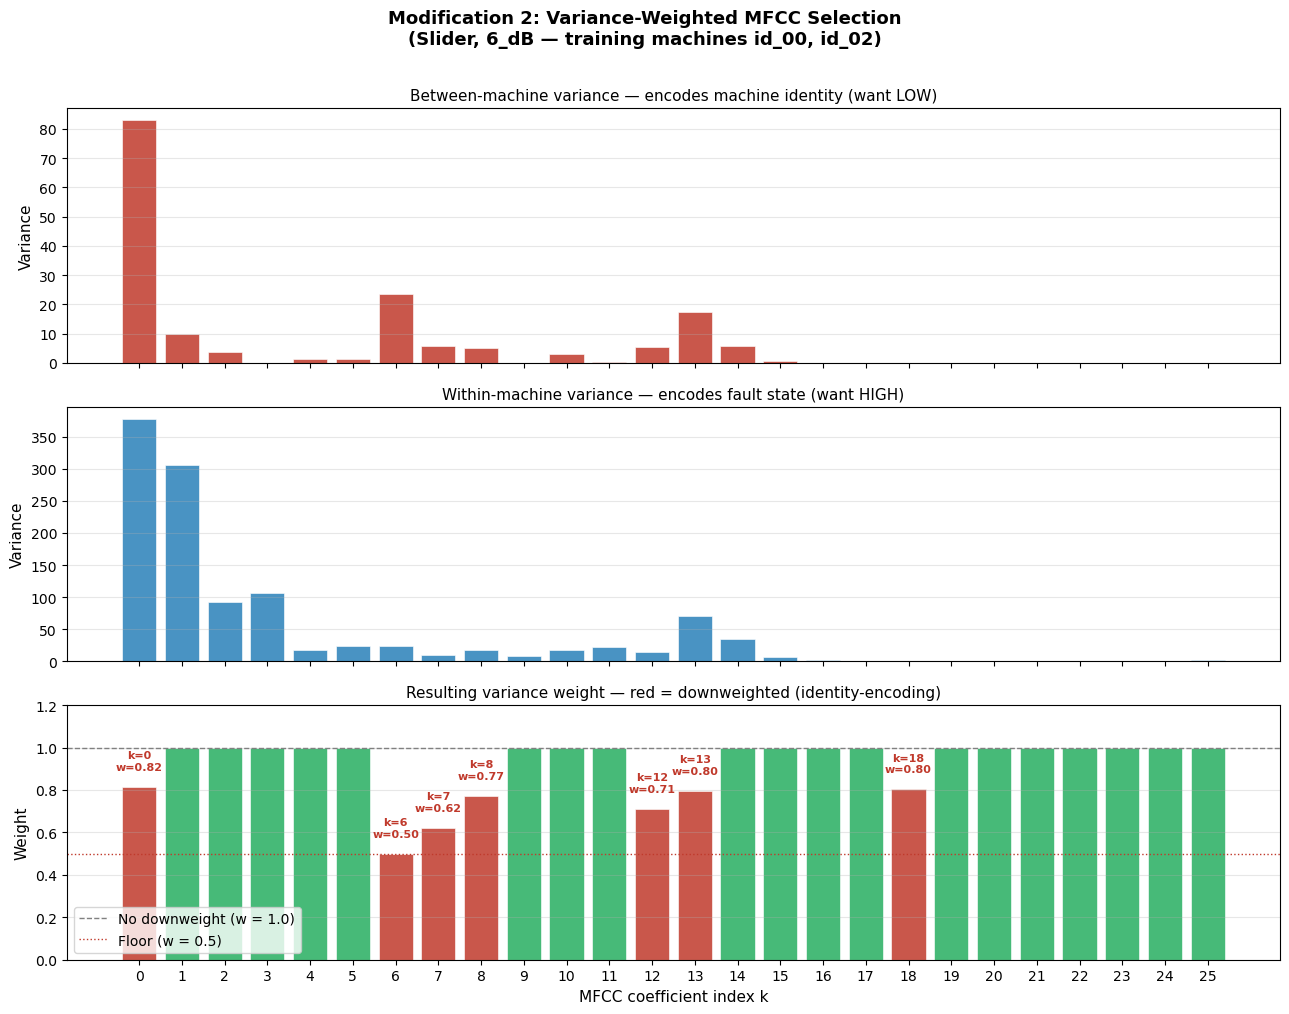

✓ Saved: C:\Users\Letizia\Documents\sound-anomaly-detection\results\figure_mod2_variance_weights_slider_6_dB.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

machine_ids_array = np.array(machine_ids_train)
unique_ids = sorted(set(machine_ids_train))
n_features = X_train.shape[1]

# Recompute variance components for plotting
within_variance = np.zeros(n_features)
for mid in unique_ids:
    mask = machine_ids_array == mid
    within_variance += X_train[mask].var(axis=0)
within_variance /= len(unique_ids)

machine_means_matrix = np.array([
    X_train[machine_ids_array == mid].mean(axis=0)
    for mid in unique_ids
])
between_variance = machine_means_matrix.var(axis=0)

epsilon = 1e-10
variance_ratio = between_variance / (within_variance + epsilon)
threshold = np.percentile(variance_ratio, 75)
high_var_idx = variance_ratio > threshold
max_ratio = variance_ratio.max()
variance_weights_plot = np.ones(n_features)
variance_weights_plot[high_var_idx] = 1.0 / (1.0 + variance_ratio[high_var_idx] / max_ratio)

x = np.arange(n_features)
x_labels = [str(i) for i in range(n_features)]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle(
    f'Modification 2: Variance-Weighted MFCC Selection\n'
    f'({machine_type.capitalize()}, {condition} — training machines {", ".join(unique_ids)})',
    fontsize=13, fontweight='bold', y=1.01
)

# Panel 1 — between-machine variance
ax = axes[0]
ax.bar(x, between_variance, color='#C0392B', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Between-machine variance — encodes machine identity (want LOW)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Panel 2 — within-machine variance
ax = axes[1]
ax.bar(x, within_variance, color='#2980B9', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Within-machine variance — encodes fault state (want HIGH)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Panel 3 — resulting weights
ax = axes[2]
bar_colors = ['#C0392B' if variance_weights_plot[i] < 1.0 else '#27AE60' for i in range(n_features)]
ax.bar(x, variance_weights_plot, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='No downweight (w = 1.0)')
ax.axhline(0.5, color='#C0392B', linestyle=':', linewidth=1, label='Floor (w = 0.5)')
ax.set_ylim([0, 1.2])
ax.set_ylabel('Weight', fontsize=11)
ax.set_xlabel('MFCC coefficient index k', fontsize=11)
ax.set_title('Resulting variance weight — red = downweighted (identity-encoding)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

for i in np.where(high_var_idx)[0]:
    ax.annotate(
        f'k={i}\nw={variance_weights_plot[i]:.2f}',
        xy=(i, variance_weights_plot[i]),
        xytext=(i, variance_weights_plot[i] + 0.08),
        ha='center', fontsize=8, color='#C0392B', fontweight='bold'
    )

plt.tight_layout()
fig_path = results_dir / f'figure_mod2_variance_weights_{machine_type}_{condition}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {fig_path}')

## Graph: Data Flow for a Single Clip

In [22]:
# ── Set configuration to pump id_04 0_dB for the data trace figure ───
import pickle
import numpy as np

machine_type    = 'pump'
condition       = '0_dB'
condition_short = '0dB'
test_id         = 'id_04'

# Load data
X_train = np.load(results_dir / f'X_train_{condition_short}_{machine_type}.npy')
X_test  = np.load(results_dir / f'X_test_{condition_short}_{machine_type}_{test_id}.npy')
y_test  = np.load(results_dir / f'y_test_{condition_short}_{machine_type}_{test_id}.npy')

with open(results_dir / f'machine_ids_train_{condition_short}_{machine_type}.pkl', 'rb') as f:
    machine_ids_train = pickle.load(f)

# Load test machine calibration data
from audio_loader import AudioLoader
loader = AudioLoader(
    data_root='C:/Users/Letizia/Documents/sound-anomaly-detection/data',
    sr=16000,
    n_mfcc=13,
    machine_type=machine_type
)
data_test_machine = loader.load_condition_dataset(
    condition=condition,
    machine_ids=[test_id],
    aggregate_method='mean_std'
)
test_normal_features = np.array(
    data_test_machine['machine_ids'][test_id]['normal']['features']
)
test_machine_mean = test_normal_features.mean(axis=0)

# Refit preprocessor
from preprocessing import PreprocessingModifications
preprocessor = PreprocessingModifications()
preprocessor.fit(X_train, machine_ids_train, apply_both=True, threshold_percentile=75.0)
preprocessor.machine_means[test_id] = test_machine_mean

# Apply preprocessing
machine_ids_test   = [test_id] * X_test.shape[0]
X_train_modified   = preprocessor.transform(X_train, machine_ids_train,
                                             apply_normalization=True, apply_weighting=True)
X_test_modified    = preprocessor.transform(X_test, machine_ids_test,
                                             apply_normalization=True, apply_weighting=True)

print(f'✓ Ready: {machine_type} {condition} {test_id}')
print(f'  X_train: {X_train.shape}  X_test: {X_test.shape}')

✓ AudioLoader initialized
  - Data root: C:\Users\Letizia\Documents\sound-anomaly-detection\data
  - Machine type: pump
  - Sampling rate: 16000 Hz
  - MFCC coefficients: 13

Loading condition: 0_dB (pump)
  Loading id_04 normal sounds... ✓ 702 clips
  Loading id_04 abnormal sounds... ✓ 100 clips
✓ PreprocessingModifications initialized

FITTING MODIFICATION 1: Per-Machine-ID Normalization
  id_00: computed mean from 1006 samples
    Sample mean values: [-349.56778    101.809746    -3.8511066   13.598431    -1.0883384]
  id_02: computed mean from 1005 samples
    Sample mean values: [-354.701      102.70811     -7.1513076   12.628088     4.688373 ]

FITTING MODIFICATION 2: Variance-Weighted MFCC Selection

  Between-ID variance (machine identity): min=0.0130, max=8.3426
  Within-ID variance (fault state):      min=0.2445, max=206.1853
  Variance ratio (between/within):       min=0.0013, max=0.9950

  Variance ratio threshold (percentile 75.0): 0.1340
  Coefficients downweighted: 7/26
 

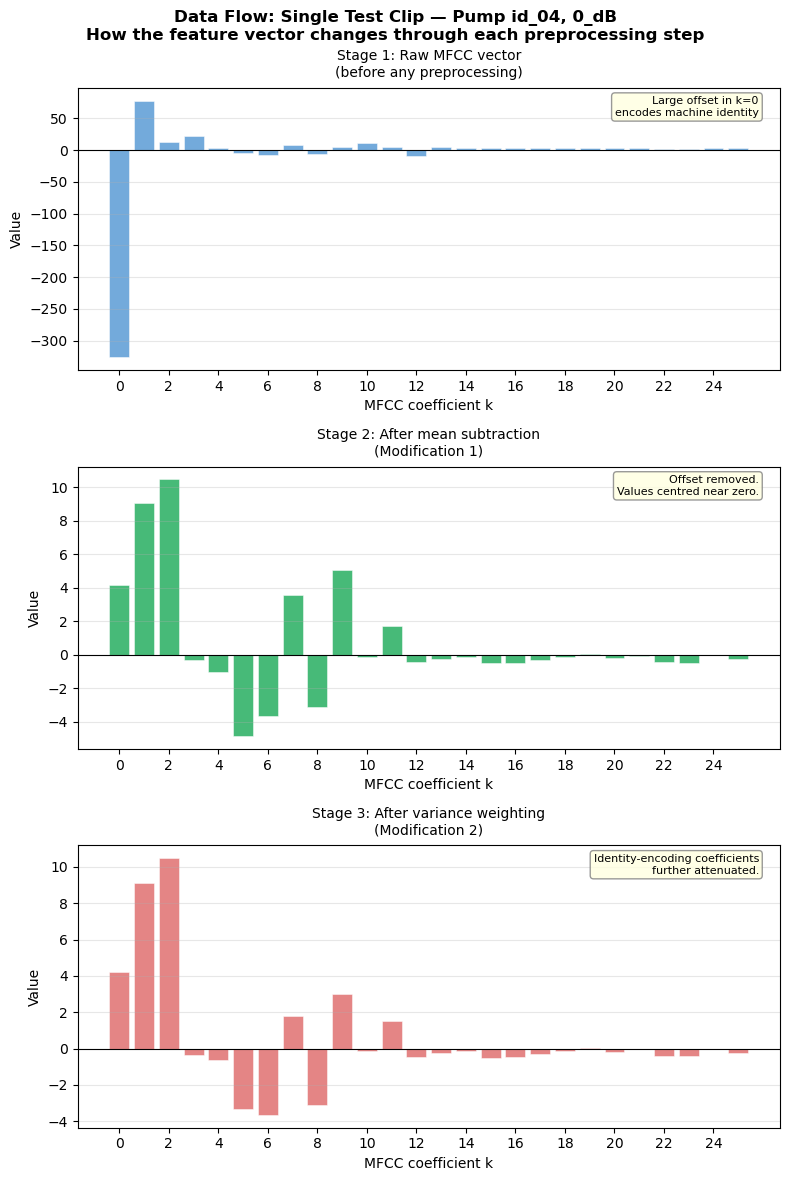

✓ Saved: C:\Users\Letizia\Documents\sound-anomaly-detection\results\figure_data_flow_pump_0_dB_id_04.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Pick the first test clip as the example
clip_idx = 0
n_features = X_train.shape[1]
k = np.arange(n_features)

# Stage 1: raw feature vector
x_raw = X_test[clip_idx]

# Stage 2: after mean subtraction only
# Reapply just normalisation to get intermediate stage
X_test_norm_only = preprocessor.transform(
    X_test,
    machine_ids_test,
    apply_normalization=True,
    apply_weighting=False
)
x_normalized = X_test_norm_only[clip_idx]

# Stage 3: fully preprocessed
x_weighted = X_test_modified[clip_idx]

stage_data = [
    (x_raw,        'Stage 1: Raw MFCC vector\n(before any preprocessing)', '#5B9BD5'),
    (x_normalized, 'Stage 2: After mean subtraction\n(Modification 1)', '#27AE60'),
    (x_weighted,   'Stage 3: After variance weighting\n(Modification 2)', '#E07070'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharey=False)
fig.suptitle(
    f'Data Flow: Single Test Clip — {machine_type.capitalize()} {test_id}, {condition}\n'
    f'How the feature vector changes through each preprocessing step',
    fontsize=12, fontweight='bold'
)

for ax, (data, title, color) in zip(axes, stage_data):
    ax.bar(k, data, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel('MFCC coefficient k', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.set_xticks(k[::2])
    ax.grid(axis='y', alpha=0.3)

# Annotations
axes[0].text(0.97, 0.97,
    'Large offset in k=0\nencodes machine identity',
    transform=axes[0].transAxes, fontsize=8, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

axes[1].text(0.97, 0.97,
    'Offset removed.\nValues centred near zero.',
    transform=axes[1].transAxes, fontsize=8, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

axes[2].text(0.97, 0.97,
    'Identity-encoding coefficients\nfurther attenuated.',
    transform=axes[2].transAxes, fontsize=8, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

plt.tight_layout()
fig_path = results_dir / f'figure_data_flow_{machine_type}_{condition}_{test_id}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {fig_path}')

## Summary

For each configuration we now have:
- Original feature sets (X_train, X_test)
- Modified feature sets (X_train_modified, X_test_modified)
- Fitted preprocessors (for reference and analysis)

**Key points:**
- ✓ Per-machine normalization removes acoustic baselines
- ✓ Variance weighting downweights identity-encoding coefficients
- ✓ Test machines calibrated using normal clips only (no leakage)
- ✓ Weighting formula documented with rationale and alternatives